## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolinea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué performance presentan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 1. Carga datos y representa la serie

In [2]:
df = pd.read_csv("data/AirPassengers.csv")
df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [3]:
df.head(20)

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
5,1949-06-01,135
6,1949-07-01,148
7,1949-08-01,148
8,1949-09-01,136
9,1949-10-01,119


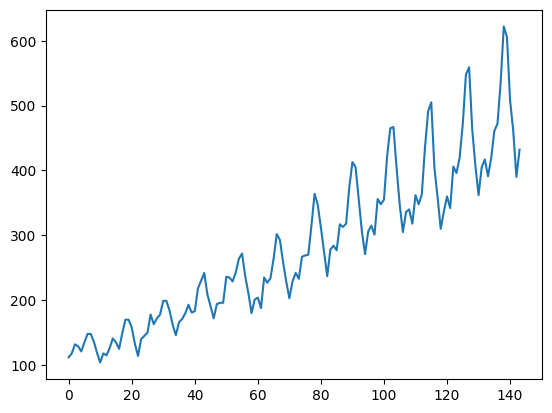

In [4]:
plt.plot(df["value"])

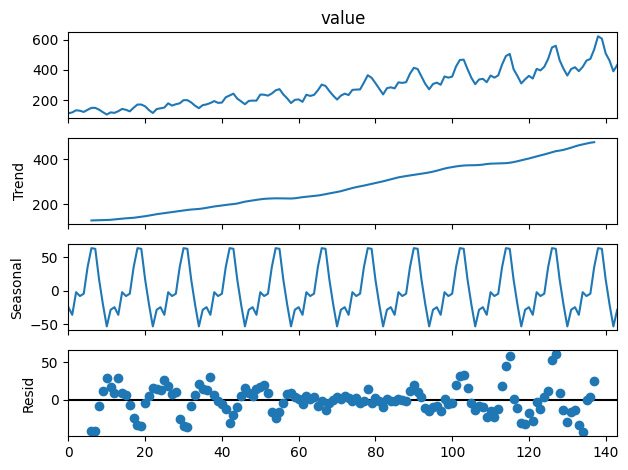

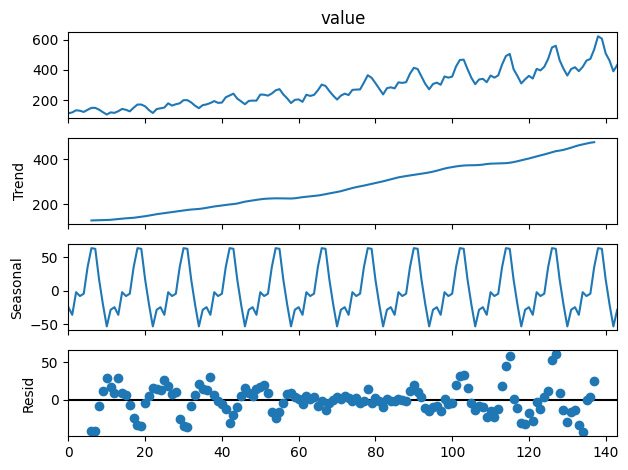

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose


# 2. Realizar la descomposición multiplicativa
# Usamos period=12 porque los datos son mensuales y el ciclo es anual
result = seasonal_decompose(df['value'], period=12)
result.plot()


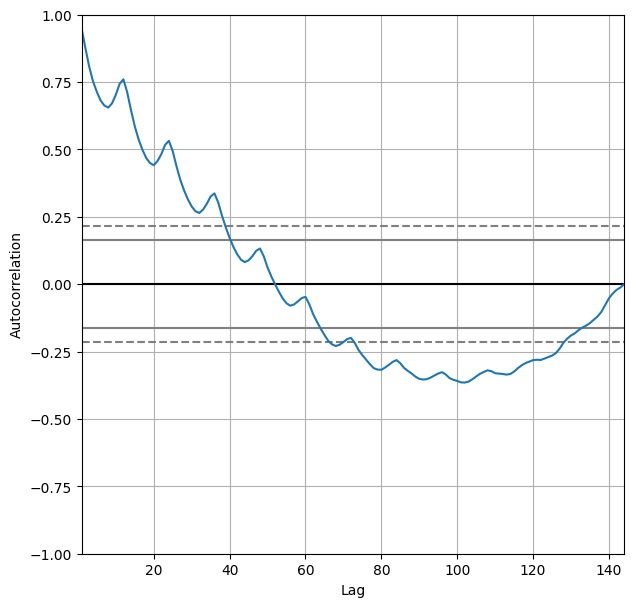

In [6]:
plt.figure(figsize=(7, 7))
pd.plotting.autocorrelation_plot(df['value'])

plt.ylim(-1, 1)
plt.grid(True)
plt.show()

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior

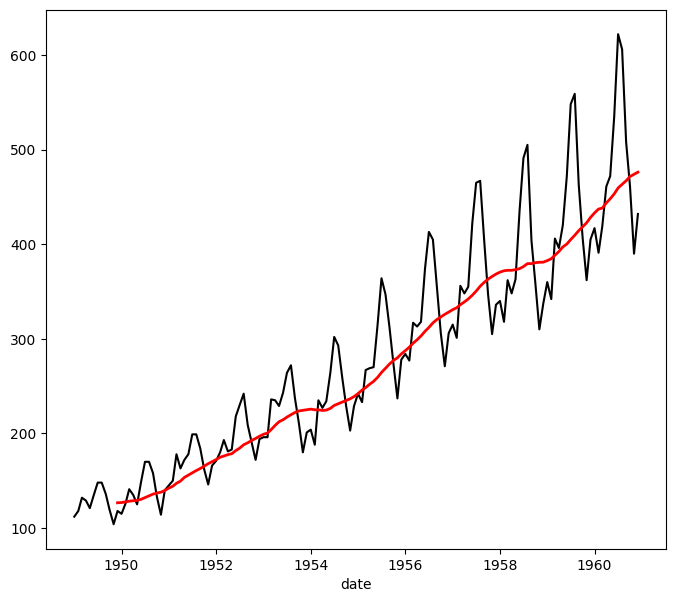

In [7]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

df['rolling_mean'] = df['value'].rolling(window=12).mean()
plt.figure(figsize=(8, 7))

plt.plot(df.index, df['value'], color='black')

plt.plot(df.index, df['rolling_mean'], color='red', linewidth=2)

plt.xlabel('date')
plt.show()

## 3. Comprueba de manera estadística si la serie es o no stationary.

El test estadístico es positivo, lo cual implica que es mucho menos probable que rechacemos la hipótesis nula (no estacionaria).

Al comparar el estadístico ADF con los valores críticos, parece que no podríamos rechazar la hipótesis nula de que la serie temporal no es estacionaria y en consecuencia afirmamos que la serie tiene una estructura que sí que es dependiente del tiempo.

Un valor p por encima del umbral sugiere que no rechazamos la hipótesis nula (no estacionario).

In [8]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    result = adfuller(timeseries)
    
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

test_stationarity(df['value'])

ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


## 4. Aplica una transformación logarítmica

In [9]:
df['log_value'] = np.log(df['value'])

In [10]:
df = df.drop('rolling_mean', axis=1)

In [11]:
df

,value,log_value
date,,
1949-01-01,112,4.718499
1949-02-01,118,4.770685
1949-03-01,132,4.882802
1949-04-01,129,4.859812
1949-05-01,121,4.795791
...,...,...
1960-08-01,606,6.406880
1960-09-01,508,6.230481
1960-10-01,461,6.133398


Podemos ver que el valor es mayor que los valores críticos, lo que significa que podemos rechazar la hipótesis nula y, a su vez, que la serie de tiempo no es estacionaria.

Sin embargo nos sigue interesando aplicar la transformación porque conseguimos estabilizar la varianza.

In [12]:
test_stationarity(df['log_value'])

ADF Statistic: -1.717017
p-value: 0.422367
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


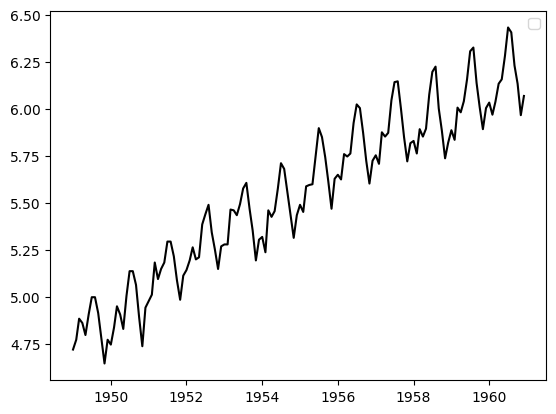

In [13]:
plt.plot(df['log_value'], color='black')
plt.legend()

## 5. Divide en train y test. Guarda 20 muestras para test.

In [34]:
dividir = df['log_value']
train = dividir[:-20]
test = dividir[-20:]

## 6. Crea tu primer modelo ARIMA

In [52]:
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = auto_arima(
    train, 
    seasonal=True, 
    stepwise=True,
    m = 12,
    trace=True, # con esto vemos el log
    error_action='ignore',
    with_intercept=True,
    suppress_warnings=True
)

# 4. Predicción y métricas (usando las 20 muestras de test)
forecast = model.predict(n_periods=20)

mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test, forecast)

# 5. Salida con el formato exacto
print(f"\nBest model:  ARIMA{model.order}{model.seasonal_order} intercept")
print(f"{model.aic()}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=-403.333, Time=1.15 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-290.649, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-399.417, Time=0.44 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-353.179, Time=0.24 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-125.472, Time=0.02 sec
 ARIMA(2,0,2)(0,1,1)[12] intercept   : AIC=-408.705, Time=1.77 sec
 ARIMA(2,0,2)(0,1,0)[12] intercept   : AIC=-382.319, Time=0.23 sec
 ARIMA(2,0,2)(0,1,2)[12] intercept   : AIC=-406.709, Time=1.52 sec
 ARIMA(2,0,2)(1,1,0)[12] intercept   : AIC=-402.095, Time=0.72 sec
 ARIMA(2,0,2)(1,1,2)[12] intercept   : AIC=-404.725, Time=1.62 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=-409.957, Time=0.71 sec
 ARIMA(1,0,2)(0,1,0)[12] intercept   : AIC=-382.629, Time=0.15 sec
 ARIMA(1,0,2)(1,1,1)[12] intercept   : AIC=-405.284, Time=0.68 sec
 ARIMA(1,0,2)(0,1,2)[12] intercept   : AIC=-407.949, Time=1.26 sec
 ARIMA(1,0,2)(1,1,0

In [53]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  124
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 211.190
Date:                              dom, 10 may 2026   AIC                           -412.379
Time:                                      11:15:54   BIC                           -398.787
Sample:                                  01-01-1949   HQIC                          -406.865
                                       - 04-01-1959                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0190      0.010      1.968      0.049     8.1e-05       0.038
ar.L1          0.6082      0.086      7.080      0.000       0.440       0.777
ar.L2          0.2355      0.090      2.622      0.009       0.059       0.411
ma.S.L12      -0.5613      0.117     -4.817      0.000      -0.790      -0.333
sigma2         0.0013      0.000      7.747      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 4.79
Prob(Q):                              0.99   Prob(JB):                         0.09
Heteroskedasticity (H):               0.41   Skew:                             0.09
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

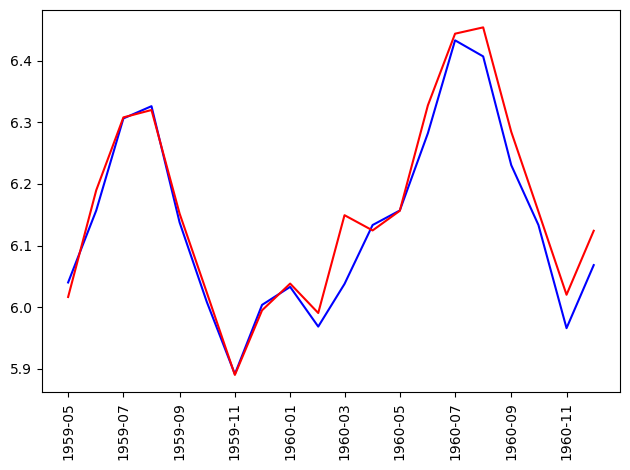

In [54]:

plt.plot(test.index, test, color='blue', label='Real', linewidth=1.5)

plt.plot(test.index, forecast, color='red', label='Predicción', linewidth=1.5)

plt.xticks(rotation=90)

plt.tight_layout()

# 6. Mostrar la gráfica
plt.show()

## 7. Representa en una gráfica los datos de test y tus predicciones.

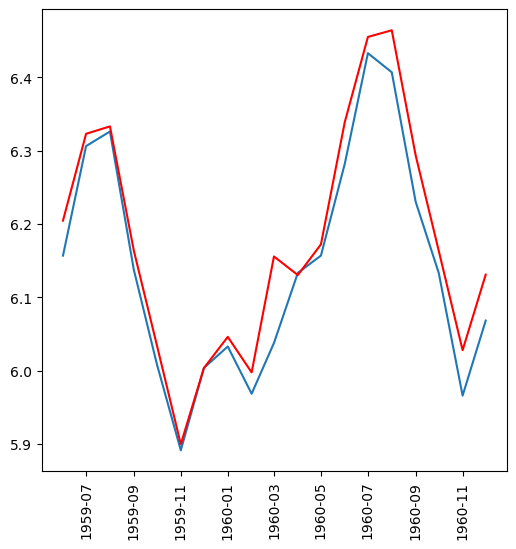

In [55]:
test

date
1959-05-01    6.040255
1959-06-01    6.156979
1959-07-01    6.306275
1959-08-01    6.326149
1959-09-01    6.137727
1959-10-01    6.008813
1959-11-01    5.891644
1959-12-01    6.003887
1960-01-01    6.033086
1960-02-01    5.968708
1960-03-01    6.037871
1960-04-01    6.133398
1960-05-01    6.156979
1960-06-01    6.282267
1960-07-01    6.432940
1960-08-01    6.406880
1960-09-01    6.230481
1960-10-01    6.133398
1960-11-01    5.966147
1960-12-01    6.068426
Name: log_value, dtype: float64

In [56]:
test

date
1959-05-01    6.040255
1959-06-01    6.156979
1959-07-01    6.306275
1959-08-01    6.326149
1959-09-01    6.137727
1959-10-01    6.008813
1959-11-01    5.891644
1959-12-01    6.003887
1960-01-01    6.033086
1960-02-01    5.968708
1960-03-01    6.037871
1960-04-01    6.133398
1960-05-01    6.156979
1960-06-01    6.282267
1960-07-01    6.432940
1960-08-01    6.406880
1960-09-01    6.230481
1960-10-01    6.133398
1960-11-01    5.966147
1960-12-01    6.068426
Name: log_value, dtype: float64

## 8. Prueba otros modelos, a ver qué performance presentan.

In [ ]:
for i in range(1, 13):
    df[f't-{i}'] = df['log_value'].shift(i)

df = df.dropna()
df = df.drop('value', axis=1)
df = df.rename(columns={'log_value': 'value'})

In [69]:
df.head()

,value,t-1,t-2,t-3,t-4,t-5,t-6,t-7,t-8,t-9,t-10,t-11,t-12
date,,,,,,,,,,,,,
1951-01-01,4.976734,4.941642,4.736198,4.890349,5.062595,5.135798,5.135798,5.003946,4.828314,4.905275,4.948760,4.836282,4.744932
1951-02-01,5.010635,4.976734,4.941642,4.736198,4.890349,5.062595,5.135798,5.135798,5.003946,4.828314,4.905275,4.948760,4.836282
1951-03-01,5.181784,5.010635,4.976734,4.941642,4.736198,4.890349,5.062595,5.135798,5.135798,5.003946,4.828314,4.905275,4.948760
1951-04-01,5.093750,5.181784,5.010635,4.976734,4.941642,4.736198,4.890349,5.062595,5.135798,5.135798,5.003946,4.828314,4.905275
1951-05-01,5.147494,5.093750,5.181784,5.010635,4.976734,4.941642,4.736198,4.890349,5.062595,5.135798,5.135798,5.003946,4.828314


In [18]:
df.head()

,value,t-12,t-11,t-10,t-9,t-8,t-7,t-6,t-5,t-4,t-3,t-2,t-1
date,,,,,,,,,,,,,
1950-01-01,4.744932,4.718499,4.770685,4.882802,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685
1950-02-01,4.836282,4.770685,4.882802,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932
1950-03-01,4.948760,4.882802,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932,4.836282
1950-04-01,4.905275,4.859812,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932,4.836282,4.948760
1950-05-01,4.828314,4.795791,4.905275,4.997212,4.997212,4.912655,4.779123,4.644391,4.770685,4.744932,4.836282,4.948760,4.905275


In [83]:
X = df.iloc[:,1:].values
y = df.iloc[:, 0].values

X_train = X[:113]
X_test = X[101:]
y_train = y[:113]
y_test = y[101:]

print("Shape X_train:", X_train.shape)
print("Shape X_test", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)


Shape X_train: (113, 12)
Shape X_test (19, 12)
Shape y_train: (113,)
Shape y_test: (19,)


In [84]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor()

tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [91]:
y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)

print(f"MSE: {mse_test}")
print(f"RMSE: {rmse_test}")
print(f"MAE: {mae_test}")


MSE: 0.00279832078783322
RMSE: 0.0528991567780926
MAE: 0.0257609734318081


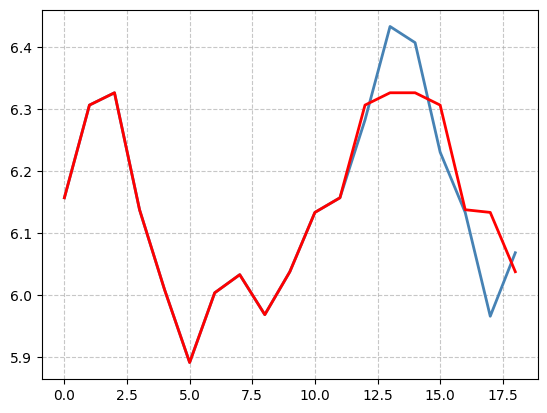

In [89]:
plt.plot(y_test, label='Real (y_test)', color='steelblue', linewidth=2)
plt.plot(y_pred_test, label='Predicción (Decision Tree)', color='red', linewidth=2)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()